# Thesis Part 1
## Baseline
### Testing ViT vs ResNet in TIL environment

**Fixes applied over v1:**
- Both ResNet and ViT use pretrained ImageNet weights
- Correct ImageNet normalization for pretrained models
- 5 tasks (20 classes each) standard Split CIFAR-100 benchmark
- Average Accuracy metric added
- BWT metric added
- 10 epochs per task

**Fixes applied over v2:**
- set the seed
-  convert the labels inside the loop


## Summary

This experiment establishes a baseline comparison between ResNet and ViT under a
TIL setup using Split CIFAR-100.

The results provide reference metrics for evaluating CL
methods applied in later experiments such as adapter-based training and
regularization approaches.

In [ ]:
!pip install timm -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import timm
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
import random

def set_seed(seed=42):
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Seed set to {seed}')

set_seed(42)

Seed set to 42


## Data Preparation

CIFAR-100 is split into **5 tasks, 20 classes each**

ImageNet normalization is used since both models are pretrained on ImageNet.

In [ ]:
# ImageNet normalization, required for pretrained ViT and ResNet
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_dataset = datasets.CIFAR100(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

NUM_TASKS = 5
CLASSES_PER_TASK = 100 // NUM_TASKS  # 20

def create_tasks(dataset, num_tasks=NUM_TASKS):
    """Split dataset into num_tasks tasks, each with an equal number of classes."""
    tasks = []
    classes_per_task = []
    targets = np.array(dataset.targets)
    for i in range(num_tasks):
        class_range = list(range(i * CLASSES_PER_TASK, (i + 1) * CLASSES_PER_TASK))
        idx = np.isin(targets, class_range).nonzero()[0]
        tasks.append(Subset(dataset, idx))
        classes_per_task.append(class_range)
    return tasks, classes_per_task

train_tasks, classes_per_task = create_tasks(train_dataset)
test_tasks,  _                = create_tasks(test_dataset)

print(f'Number of tasks: {NUM_TASKS}')
print(f'Classes per task: {CLASSES_PER_TASK}')
print(f'Train samples in Task 1: {len(train_tasks[0])}')
print(f'Test  samples in Task 1: {len(test_tasks[0])}')

100%|██████████| 169M/169M [00:03<00:00, 47.7MB/s]


Number of tasks: 5
Classes per task: 20
Train samples in Task 1: 10000
Test  samples in Task 1: 2000


## Training and Evaluation Functions

In [ ]:
def train_model(model, train_data, epochs=10, lr=1e-3):
    """Train the model on a single task dataset."""
    model.train()
    dataloader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'  Epoch {epoch+1}/{epochs} — Loss: {running_loss / len(dataloader):.4f}')


def evaluate_task(model, task_data, task_classes):
    """
    Evaluate model on a single task.
    Uses task-masked logits (TIL setting: task identity known at inference).
    """
    model.eval()
    correct, total = 0, 0
    dataloader = DataLoader(task_data, batch_size=64, num_workers=2)
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Mask logits to only the classes in this task (TIL setting)
            outputs_task = outputs[:, task_classes]

            # Remap global labels to local task indices (0..CLASSES_PER_TASK-1)
            # Vectorised label mapping
            label_map = torch.full((100,), -1, dtype=torch.long)
            for local_idx, global_idx in enumerate(task_classes):
                label_map[global_idx] = local_idx
            labels_local = label_map[labels.cpu()].to(device)

            _, preds = torch.max(outputs_task, 1)
            correct += (preds == labels_local).sum().item()
            total   += labels.size(0)
    return correct / total * 100


def evaluate_all_tasks(model, test_tasks, classes_per_task, num_seen):
    """
    Evaluate on ALL tasks seen so far (tasks 0..num_seen-1).
    Returns list of accuracies, one per seen task.
    """
    accs = []
    for t in range(num_seen):
        acc = evaluate_task(model, test_tasks[t], classes_per_task[t])
        accs.append(acc)
    return accs

## Metrics

The following metrics are computed:

- **Average Accuracy**: mean accuracy across all tasks after full training
- **Forgetting (F_avg)**: average drop from peak accuracy to final accuracy per task
- **Backward Transfer (BWT)**: influence of new task learning on previously learned tasks

In [ ]:
def compute_metrics(acc_matrix):
    """
    acc_matrix[t] = list of accuracies on tasks 0..t after training on task t.
    acc_matrix is a list of lists, where acc_matrix[t][i] = A_i^t
    (accuracy on task i after learning task t).

    Returns:
        avg_acc    : Average accuracy after learning all tasks
        f_avg      : Average forgetting across tasks 0..T-2
        bwt        : Backward transfer
        forgetting : Per-task forgetting list
    """
    T = len(acc_matrix)

    # Build full T x T matrix (NaN for tasks not yet seen)
    full = np.full((T, T), np.nan)
    for t in range(T):
        for i in range(len(acc_matrix[t])):
            full[t][i] = acc_matrix[t][i]

    avg_acc = np.nanmean(full[T - 1])

    forgetting = []
    for i in range(T - 1):
        col = full[:, i]
        max_acc   = np.nanmax(col)
        final_acc = full[T - 1][i]
        forgetting.append(max_acc - final_acc)

    f_avg = np.mean(forgetting)

    bwt_vals = []
    for i in range(T - 1):
        a_i_T = full[T - 1][i]   # accuracy on task i after all tasks
        a_i_i = full[i][i]       # accuracy on task i right after learning it
        bwt_vals.append(a_i_T - a_i_i)
    bwt = np.mean(bwt_vals)

    return avg_acc, f_avg, bwt, forgetting

## Baseline 1: ResNet-18 (Pretrained)

ResNet-18 pretrained on ImageNet, fine-tuned sequentially on each task.
No CL strategy applied. This is the naive sequential fine-tuning baseline.

In [ ]:
# ResNet-18 pretrained on ImageNet
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 100)  # 100 output classes
resnet = resnet.to(device)

# acc_matrix[t] = accuracies on all tasks seen so far, after training on task t
resnet_acc_matrix = []

for t_id in range(NUM_TASKS):
    print(f'\n--- ResNet: Training on Task {t_id + 1}/{NUM_TASKS} ---')
    train_model(resnet, train_tasks[t_id], epochs=10, lr=1e-3)

    # Evaluate on ALL tasks seen so far (not just current)
    accs = evaluate_all_tasks(resnet, test_tasks, classes_per_task, num_seen=t_id + 1)
    resnet_acc_matrix.append(accs)
    print(f'  Accuracies after Task {t_id + 1}: {[f"{a:.2f}" for a in accs]}')

resnet_avg_acc, resnet_f_avg, resnet_bwt, resnet_forgetting = compute_metrics(resnet_acc_matrix)

print('\n=== ResNet Final Results ===')
print(f'  Average Accuracy : {resnet_avg_acc:.2f}%')
print(f'  Average Forgetting: {resnet_f_avg:.2f}%')
print(f'  Backward Transfer : {resnet_bwt:.2f}%')
print(f'  Per-task Forgetting: {[f"{f:.2f}" for f in resnet_forgetting]}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 106MB/s]



--- ResNet: Training on Task 1/5 ---
  Epoch 1/10 — Loss: 1.0509
  Epoch 2/10 — Loss: 0.5742
  Epoch 3/10 — Loss: 0.3365
  Epoch 4/10 — Loss: 0.2701
  Epoch 5/10 — Loss: 0.2019
  Epoch 6/10 — Loss: 0.1022
  Epoch 7/10 — Loss: 0.0722
  Epoch 8/10 — Loss: 0.1127
  Epoch 9/10 — Loss: 0.1427
  Epoch 10/10 — Loss: 0.0875
  Accuracies after Task 1: ['82.15']

--- ResNet: Training on Task 2/5 ---
  Epoch 1/10 — Loss: 1.9798
  Epoch 2/10 — Loss: 0.5491
  Epoch 3/10 — Loss: 0.2320
  Epoch 4/10 — Loss: 0.1198
  Epoch 5/10 — Loss: 0.1039
  Epoch 6/10 — Loss: 0.1073
  Epoch 7/10 — Loss: 0.0781
  Epoch 8/10 — Loss: 0.0440
  Epoch 9/10 — Loss: 0.0409
  Epoch 10/10 — Loss: 0.0419
  Accuracies after Task 2: ['17.70', '81.85']

--- ResNet: Training on Task 3/5 ---
  Epoch 1/10 — Loss: 3.4022
  Epoch 2/10 — Loss: 0.6393
  Epoch 3/10 — Loss: 0.2631
  Epoch 4/10 — Loss: 0.1309
  Epoch 5/10 — Loss: 0.0632
  Epoch 6/10 — Loss: 0.0170
  Epoch 7/10 — Loss: 0.0610
  Epoch 8/10 — Loss: 0.1254
  Epoch 9/10 — Lo

## Baseline 2: ViT-Tiny (Pretrained)

ViT-Tiny pretrained on ImageNet via `timm`, fine-tuned sequentially on each task.
A smaller learning rate is used to avoid disturbing pretrained representations.
No CL strategy applied and same naive sequential fine-tuning as ResNet.

In [ ]:
# ViT-Tiny pretrained on ImageNet
vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=100)
vit = vit.to(device)

vit_acc_matrix = []

for t_id in range(NUM_TASKS):
    print(f'\n--- ViT: Training on Task {t_id + 1}/{NUM_TASKS} ---')
    train_model(vit, train_tasks[t_id], epochs=10, lr=3e-5)  # small LR for pretrained ViT

    # Evaluate on ALL tasks seen so far
    accs = evaluate_all_tasks(vit, test_tasks, classes_per_task, num_seen=t_id + 1)
    vit_acc_matrix.append(accs)
    print(f'  Accuracies after Task {t_id + 1}: {[f"{a:.2f}" for a in accs]}')

vit_avg_acc, vit_f_avg, vit_bwt, vit_forgetting = compute_metrics(vit_acc_matrix)

print('\n=== ViT Final Results ===')
print(f'  Average Accuracy : {vit_avg_acc:.2f}%')
print(f'  Average Forgetting: {vit_f_avg:.2f}%')
print(f'  Backward Transfer : {vit_bwt:.2f}%')
print(f'  Per-task Forgetting: {[f"{f:.2f}" for f in vit_forgetting]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


--- ViT: Training on Task 1/5 ---
  Epoch 1/10 — Loss: 1.5505
  Epoch 2/10 — Loss: 0.2997
  Epoch 3/10 — Loss: 0.1218
  Epoch 4/10 — Loss: 0.0496
  Epoch 5/10 — Loss: 0.0224
  Epoch 6/10 — Loss: 0.0119
  Epoch 7/10 — Loss: 0.0060
  Epoch 8/10 — Loss: 0.0039
  Epoch 9/10 — Loss: 0.0029
  Epoch 10/10 — Loss: 0.0023
  Accuracies after Task 1: ['93.50']

--- ViT: Training on Task 2/5 ---
  Epoch 1/10 — Loss: 1.8060
  Epoch 2/10 — Loss: 0.2706
  Epoch 3/10 — Loss: 0.1183
  Epoch 4/10 — Loss: 0.0513
  Epoch 5/10 — Loss: 0.0238
  Epoch 6/10 — Loss: 0.0161
  Epoch 7/10 — Loss: 0.0076
  Epoch 8/10 — Loss: 0.0054
  Epoch 9/10 — Loss: 0.0039
  Epoch 10/10 — Loss: 0.0028
  Accuracies after Task 2: ['60.20', '94.70']

--- ViT: Training on Task 3/5 ---
  Epoch 1/10 — Loss: 1.8058
  Epoch 2/10 — Loss: 0.3620
  Epoch 3/10 — Loss: 0.1923
  Epoch 4/10 — Loss: 0.1015
  Epoch 5/10 — Loss: 0.0647
  Epoch 6/10 — Loss: 0.0388
  Epoch 7/10 — Loss: 0.0217
  Epoch 8/10 — Loss: 0.0153
  Epoch 9/10 — Loss: 0.011

## Results Summary Table

In [ ]:
print('\n' + '='*55)
print(f'{"Metric":<30} {"ResNet-18":>10} {"ViT-Tiny":>10}')
print('='*55)
print(f'{"Average Accuracy (%)":<30} {resnet_avg_acc:>10.2f} {vit_avg_acc:>10.2f}')
print(f'{"Average Forgetting (%)":<30} {resnet_f_avg:>10.2f} {vit_f_avg:>10.2f}')
print(f'{"Backward Transfer (%)":<30} {resnet_bwt:>10.2f} {vit_bwt:>10.2f}')
print('='*55)


Metric                          ResNet-18   ViT-Tiny
Average Accuracy (%)                24.22      41.91
Average Forgetting (%)              69.17      63.26
Backward Transfer (%)              -69.17     -63.26


## Visualisation

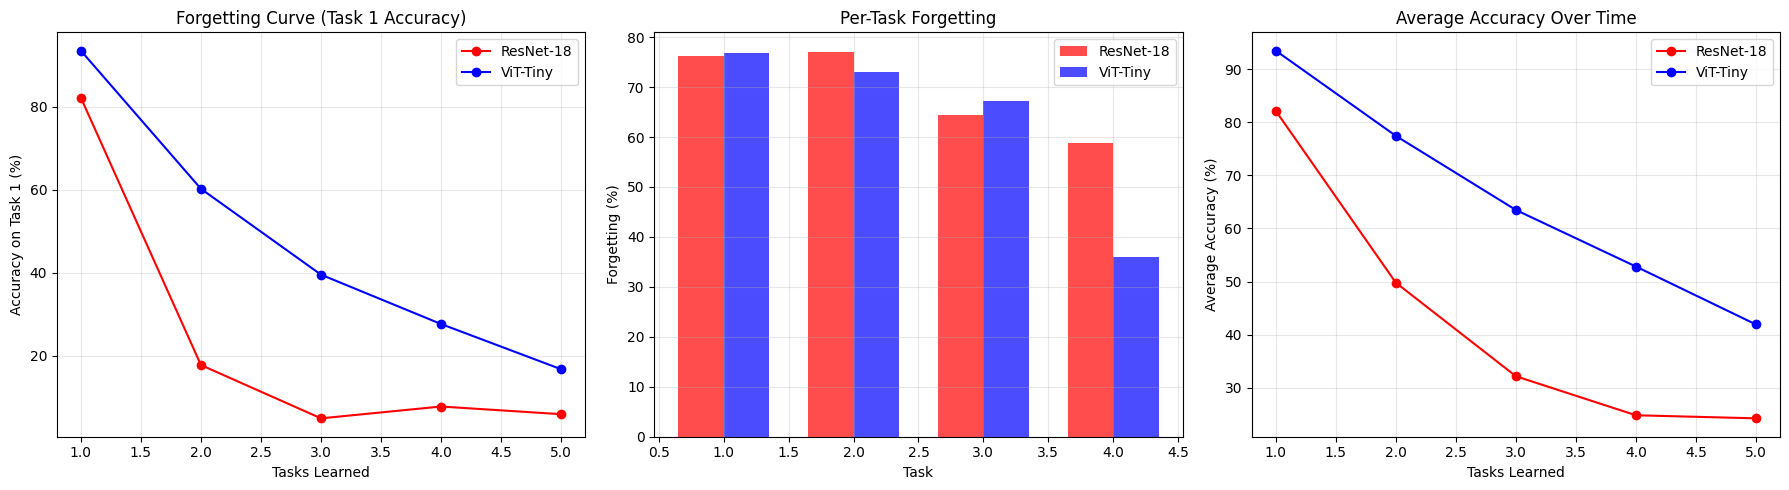

Figure saved as baseline_results.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Task accuracy after each training stage ---
ax = axes[0]
# Show accuracy on task 1 as more tasks are learned (forgetting curve)
resnet_task1 = [resnet_acc_matrix[t][0] for t in range(NUM_TASKS)]
vit_task1    = [vit_acc_matrix[t][0]    for t in range(NUM_TASKS)]
ax.plot(range(1, NUM_TASKS + 1), resnet_task1, 'r-o', label='ResNet-18')
ax.plot(range(1, NUM_TASKS + 1), vit_task1,    'b-o', label='ViT-Tiny')
ax.set_xlabel('Tasks Learned')
ax.set_ylabel('Accuracy on Task 1 (%)')
ax.set_title('Forgetting Curve (Task 1 Accuracy)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Per-task forgetting ---
ax = axes[1]
x = np.arange(1, NUM_TASKS)  # tasks 1..T-1 (last task has no forgetting)
width = 0.35
ax.bar(x - width/2, resnet_forgetting, width, label='ResNet-18', color='red',  alpha=0.7)
ax.bar(x + width/2, vit_forgetting,    width, label='ViT-Tiny',  color='blue', alpha=0.7)
ax.set_xlabel('Task')
ax.set_ylabel('Forgetting (%)')
ax.set_title('Per-Task Forgetting')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Average accuracy across all tasks after each stage ---
ax = axes[2]
resnet_avg_over_time = [np.mean(resnet_acc_matrix[t]) for t in range(NUM_TASKS)]
vit_avg_over_time    = [np.mean(vit_acc_matrix[t])    for t in range(NUM_TASKS)]
ax.plot(range(1, NUM_TASKS + 1), resnet_avg_over_time, 'r-o', label='ResNet-18')
ax.plot(range(1, NUM_TASKS + 1), vit_avg_over_time,    'b-o', label='ViT-Tiny')
ax.set_xlabel('Tasks Learned')
ax.set_ylabel('Average Accuracy (%)')
ax.set_title('Average Accuracy Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as baseline_results.png')

## Accuracy Matrix Heatmap

Shows accuracy on task i after training on task t.
- Diagonal = accuracy right after learning each task.
- Below diagonal = forgetting (how much accuracy drops as more tasks are learned).

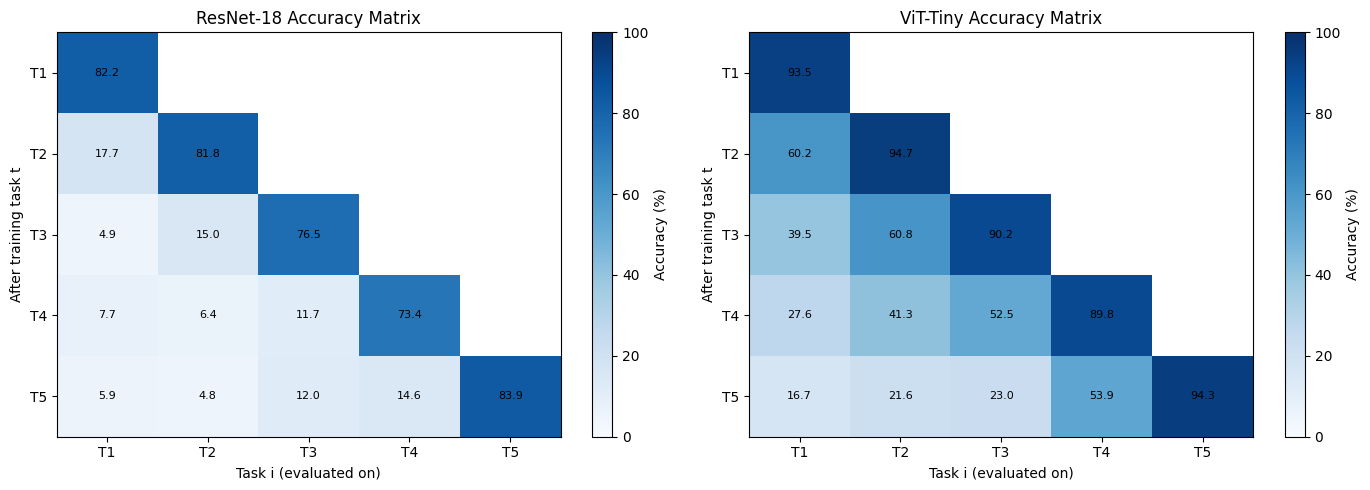

Figure saved as accuracy_matrix.png


In [ ]:
def build_full_matrix(acc_matrix, T):
    """Build T x T matrix from list-of-lists. NaN for unseen tasks."""
    full = np.full((T, T), np.nan)
    for t in range(T):
        for i in range(len(acc_matrix[t])):
            full[t][i] = acc_matrix[t][i]
    return full

resnet_matrix = build_full_matrix(resnet_acc_matrix, NUM_TASKS)
vit_matrix    = build_full_matrix(vit_acc_matrix,    NUM_TASKS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, matrix, title in zip(axes,
                              [resnet_matrix, vit_matrix],
                              ['ResNet-18 Accuracy Matrix', 'ViT-Tiny Accuracy Matrix']):
    im = ax.imshow(matrix, vmin=0, vmax=100, cmap='Blues', aspect='auto')
    ax.set_xlabel('Task i (evaluated on)')
    ax.set_ylabel('After training task t')
    ax.set_title(title)
    ax.set_xticks(range(NUM_TASKS))
    ax.set_yticks(range(NUM_TASKS))
    ax.set_xticklabels([f'T{i+1}' for i in range(NUM_TASKS)])
    ax.set_yticklabels([f'T{t+1}' for t in range(NUM_TASKS)])
    for t in range(NUM_TASKS):
        for i in range(NUM_TASKS):
            val = matrix[t][i]
            if not np.isnan(val):
                ax.text(i, t, f'{val:.1f}', ha='center', va='center',
                        fontsize=8, color='black')
    plt.colorbar(im, ax=ax, label='Accuracy (%)')

plt.tight_layout()
plt.savefig('accuracy_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as accuracy_matrix.png')